# Hormuz Cable Risk
## Geopolitical Risk Index for Submarine Cable Infrastructure in the Strait of Hormuz

This notebook documents the full analysis pipeline: data sources, methodology, results, and limitations.

**Data coverage:** 1989 – February 2026  
**Author:** Carolina Cruz  
**Repository:** [github.com/CarolinaMCruz/hormuz-cable-risk](https://github.com/CarolinaMCruz/hormuz-cable-risk)

## 1. Context

The Strait of Hormuz is the world's most critical maritime chokepoint for oil transport. Less discussed is its role as a submarine cable corridor connecting the Gulf states to Europe and Asia.

This project asks: **if cables in this zone are damaged, which countries lose the most digital connectivity?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load processed datasets
df_cables   = pd.read_csv('../data/processed/cables.csv')
df_landing  = pd.read_csv('../data/processed/landing_points.csv')
df_conflicto = pd.read_csv('../data/processed/ucdp_gulf_zone.csv', low_memory=False)
df_indice   = pd.read_csv('../data/processed/indice_riesgo.csv')

print(f"Cables: {len(df_cables)}")
print(f"Landing points: {len(df_landing)}")
print(f"Conflict events: {len(df_conflicto):,}")
print(f"Countries in index: {len(df_indice)}")

Cables: 691
Landing points: 3157
Conflict events: 25,673
Countries in index: 10


## 2. Infrastructure Overview

### 2.1 Submarine Cables in the Gulf Zone

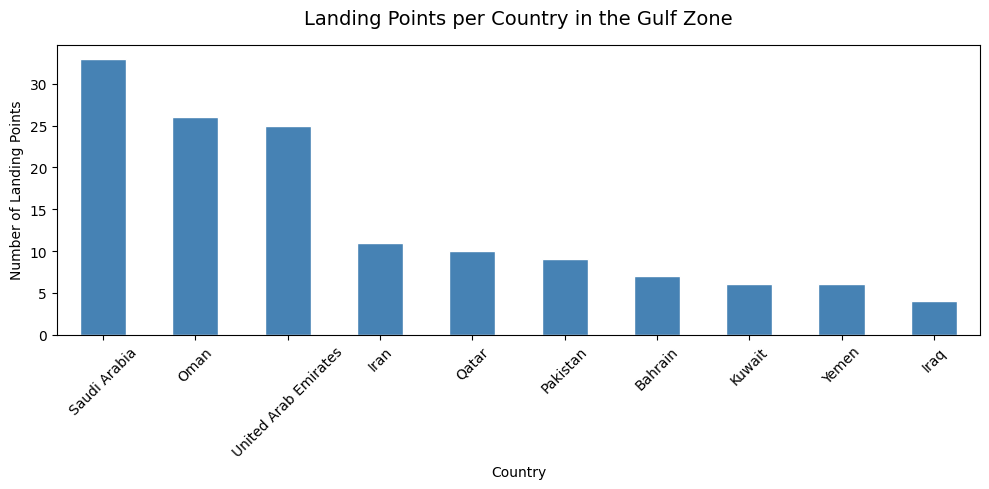


Total landing points in zone: 137
country
Saudi Arabia            33
Oman                    26
United Arab Emirates    25
Iran                    11
Qatar                   10
Pakistan                 9
Bahrain                  7
Kuwait                   6
Yemen                    6
Iraq                     4


In [4]:
ZONA = [
    "Iran", "Oman", "Yemen", "Saudi Arabia",
    "United Arab Emirates", "Qatar", "Kuwait", "Bahrain",
    "Pakistan", "Iraq"
]

# Landing points per country in the Gulf zone
lp_zona = df_landing[df_landing["country"].isin(ZONA)]
conteo = lp_zona["country"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
conteo.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Landing Points per Country in the Gulf Zone", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Landing Points")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTotal landing points in zone: {len(lp_zona)}")
print(conteo.to_string())

### 2.2 Cables per Country

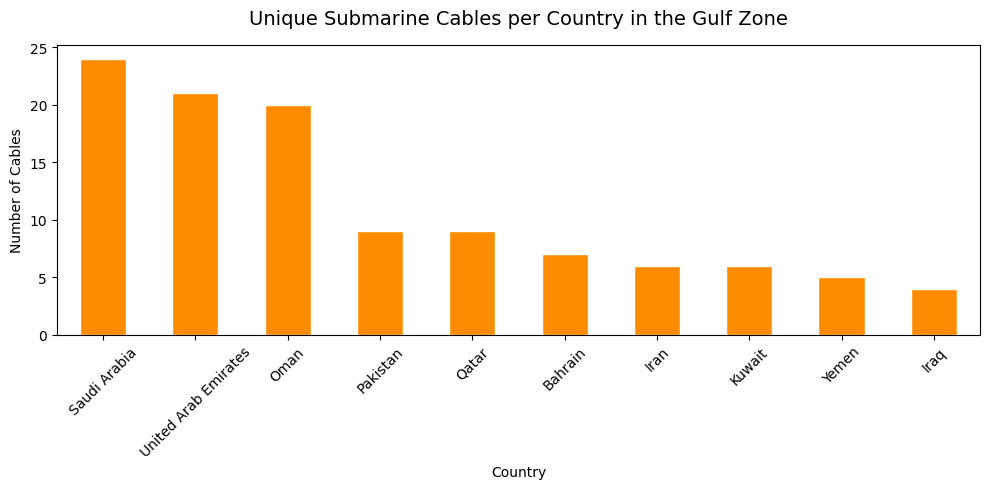


Cables per country:
country
Saudi Arabia            24
United Arab Emirates    21
Oman                    20
Pakistan                 9
Qatar                    9
Bahrain                  7
Iran                     6
Kuwait                   6
Yemen                    5
Iraq                     4


In [5]:
# Unique cables per country in zone
cables_pais = (
    lp_zona.groupby("country")["cable_id"]
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
cables_pais.plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.set_title("Unique Submarine Cables per Country in the Gulf Zone", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Cables")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nCables per country:")
print(cables_pais.to_string())

### 2.3 Conflict Events in the Gulf Zone (1989-2026)

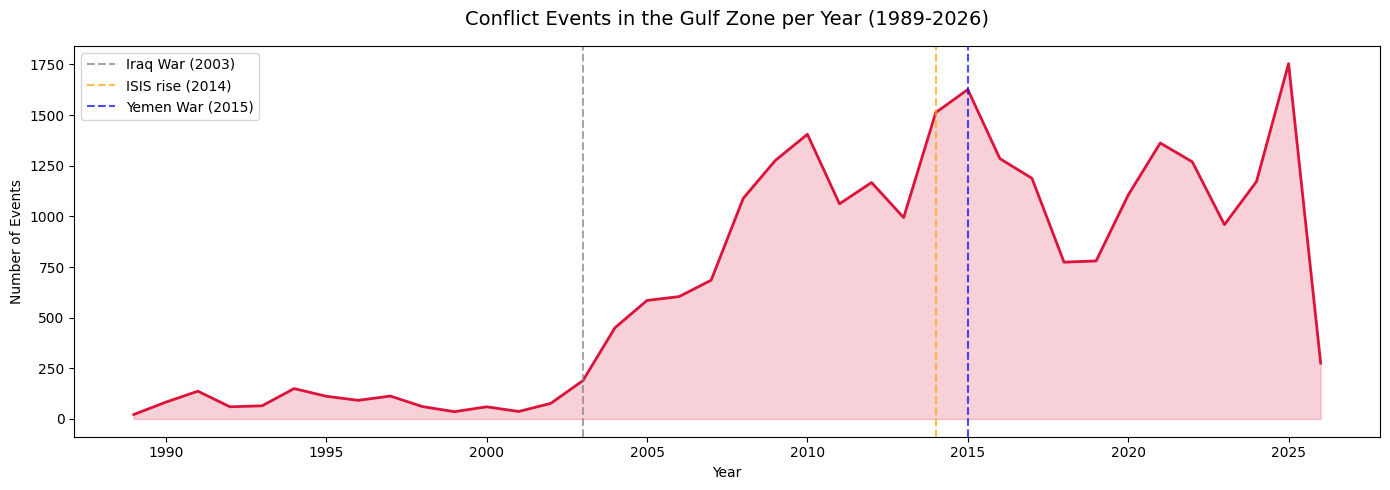

In [6]:
df_conflicto["date_start"] = pd.to_datetime(df_conflicto["date_start"])
df_conflicto["year"] = df_conflicto["date_start"].dt.year
df_conflicto["country"] = df_conflicto["country"].replace({"Yemen (North Yemen)": "Yemen"})

# Events per year
eventos_año = df_conflicto.groupby("year").size()

fig, ax = plt.subplots(figsize=(14, 5))
eventos_año.plot(kind="line", ax=ax, color="crimson", linewidth=2)
ax.fill_between(eventos_año.index, eventos_año.values, alpha=0.2, color="crimson")
ax.set_title("Conflict Events in the Gulf Zone per Year (1989-2026)", fontsize=14, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Events")
ax.axvline(x=2003, color="gray", linestyle="--", alpha=0.7, label="Iraq War (2003)")
ax.axvline(x=2014, color="orange", linestyle="--", alpha=0.7, label="ISIS rise (2014)")
ax.axvline(x=2015, color="blue", linestyle="--", alpha=0.7, label="Yemen War (2015)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Conflict Events by Country


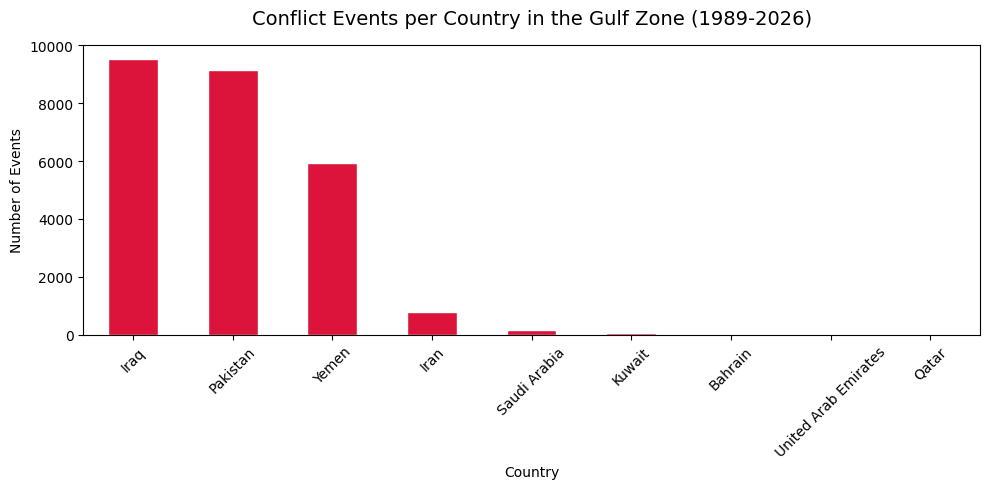


Events per country:
country
Iraq                    9540
Pakistan                9153
Yemen                   5941
Iran                     794
Saudi Arabia             173
Kuwait                    41
Bahrain                   24
United Arab Emirates       5
Qatar                      2


In [8]:
# Events per country
eventos_pais = df_conflicto["country"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
eventos_pais.plot(kind="bar", ax=ax, color="crimson", edgecolor="white")
ax.set_title("Conflict Events per Country in the Gulf Zone (1989-2026)", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Events")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nEvents per country:")
print(eventos_pais.to_string())

## 3. Digital Vulnerability Index

### 3.1 Risk Index by Country

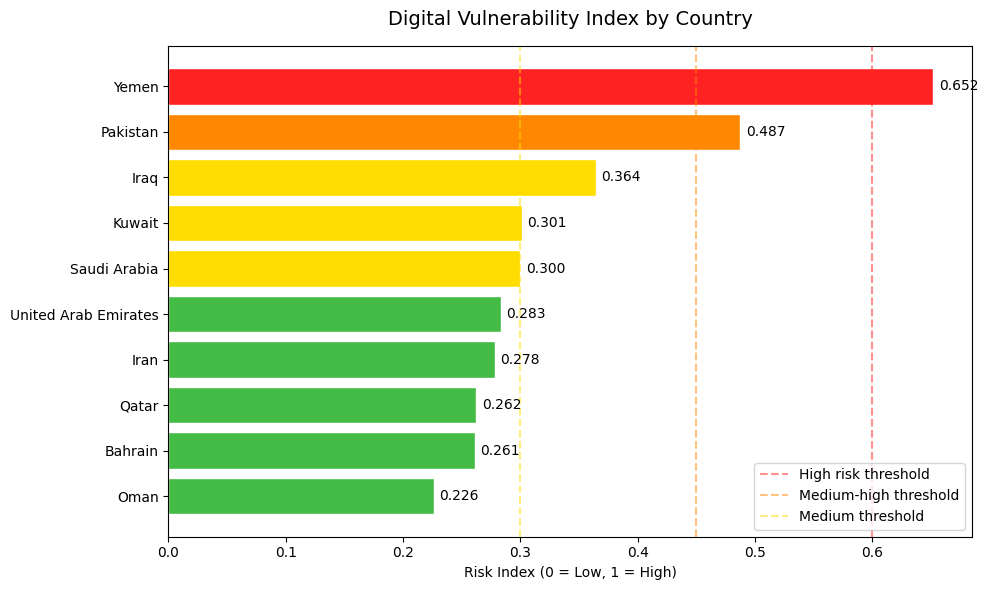

In [9]:
df_indice_sorted = df_indice.sort_values("indice_riesgo", ascending=True)

colors = []
for val in df_indice_sorted["indice_riesgo"]:
    if val >= 0.6:
        colors.append("#ff2222")
    elif val >= 0.45:
        colors.append("#ff8800")
    elif val >= 0.30:
        colors.append("#ffdd00")
    else:
        colors.append("#44bb44")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_indice_sorted["country"], df_indice_sorted["indice_riesgo"],
               color=colors, edgecolor="white")

ax.set_title("Digital Vulnerability Index by Country", fontsize=14, pad=15)
ax.set_xlabel("Risk Index (0 = Low, 1 = High)")
ax.axvline(x=0.60, color="#ff2222", linestyle="--", alpha=0.5, label="High risk threshold")
ax.axvline(x=0.45, color="#ff8800", linestyle="--", alpha=0.5, label="Medium-high threshold")
ax.axvline(x=0.30, color="#ffdd00", linestyle="--", alpha=0.5, label="Medium threshold")

for bar, val in zip(bars, df_indice_sorted["indice_riesgo"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 3.2 Index Components Breakdown

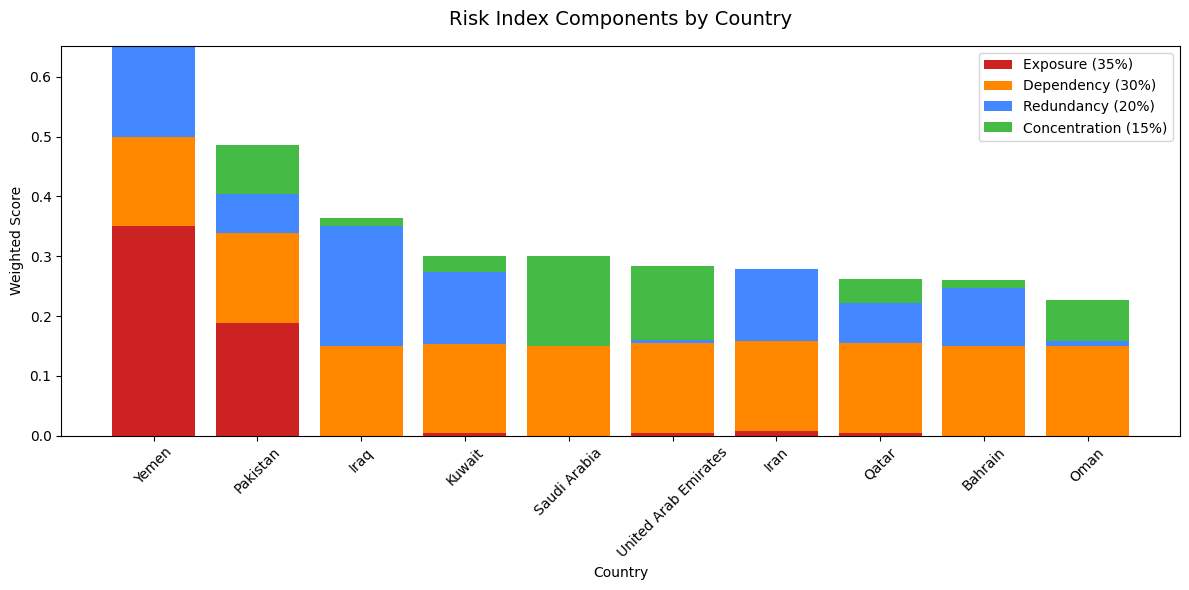

In [10]:
df_plot = df_indice.sort_values("indice_riesgo", ascending=False).copy()

# Weighted components
df_plot["w_exposicion"]    = df_plot["n_exposicion"] * 0.35
df_plot["w_dependencia"]   = df_plot["n_dependencia"] * 0.30
df_plot["w_redundancia"]   = df_plot["n_redundancia"] * 0.20
df_plot["w_concentracion"] = df_plot["n_concentracion"] * 0.15

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df_plot["country"], df_plot["w_exposicion"],    label="Exposure (35%)",       color="#cc2222")
ax.bar(df_plot["country"], df_plot["w_dependencia"],   label="Dependency (30%)",     color="#ff8800",
       bottom=df_plot["w_exposicion"])
ax.bar(df_plot["country"], df_plot["w_redundancia"],   label="Redundancy (20%)",     color="#4488ff",
       bottom=df_plot["w_exposicion"] + df_plot["w_dependencia"])
ax.bar(df_plot["country"], df_plot["w_concentracion"], label="Concentration (15%)",  color="#44bb44",
       bottom=df_plot["w_exposicion"] + df_plot["w_dependencia"] + df_plot["w_redundancia"])

ax.set_title("Risk Index Components by Country", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Weighted Score")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. Key Findings

In [13]:
print("=" * 55)
print("  KEY FINDINGS")
print("=" * 55)

# País más vulnerable
top = df_indice.iloc[0]
print(f"\n1. Most vulnerable country: {top['country']}")
print(f"   Risk index: {top['indice_riesgo']}")
print(f"   Cables: {int(top['cables_totales'])} (all in risk zone)")
print(f"   Conflict events near cables: {int(top['eventos_totales'])}")

# País más resiliente
bottom = df_indice.iloc[-1]
print(f"\n2. Most resilient country: {bottom['country']}")
print(f"   Risk index: {bottom['indice_riesgo']}")
print(f"   Cables: {int(bottom['cables_totales'])} (high redundancy)")
print(f"   Conflict events near cables: {int(bottom['eventos_totales'])}")

# Cables críticos
print(f"\n3. Critical cables (pass through Iran or Yemen):")
criticos = df_landing[
    df_landing["country"].isin(["Iran", "Yemen"])
]["cable_name"].value_counts()
for cable, _ in criticos.head(5).items():
    print(f"   - {cable}")

# Concentración
print(f"\n4. Single points of failure:")
cables_por_lp = df_landing.groupby(["landing_id","landing_name","country"]).size().reset_index(name="n_cables")
spof = cables_por_lp[
    cables_por_lp["country"].isin(["Iran","Yemen","Iraq"]) &
    (cables_por_lp["n_cables"] >= 3)
].sort_values("n_cables", ascending=False)
print(spof[["landing_name","country","n_cables"]].to_string(index=False))

  KEY FINDINGS

1. Most vulnerable country: Yemen
   Risk index: 0.652
   Cables: 5 (all in risk zone)
   Conflict events near cables: 569

2. Most resilient country: Oman
   Risk index: 0.226
   Cables: 20 (high redundancy)
   Conflict events near cables: 0

3. Critical cables (pass through Iran or Yemen):
   - FALCON
   - Kuwait-Iran
   - OMRAN/EPEG
   - Pishgaman Oman Iran (POI) Network
   - Aden-Djibouti

4. Single points of failure:
      landing_name country  n_cables
      Al Faw, Iraq    Iraq         4
Al Hudaydah, Yemen   Yemen         3
    Chabahar, Iran    Iran         3
        Jask, Iran    Iran         3


## 5. Limitations

- **UCDP coverage:** Verified armed conflict events only. Naval operations, cyber attacks, and geopolitical pressure are not captured, likely underestimating Iran's actual risk.
- **Cable geometry:** TeleGeography routes are cartographic representations, not precise engineering data.
- **Exposure radius:** 50km buffer around landing points. Cables between landing points are not analyzed.
- **AISstream:** Real-time vessel tracking was tested but the service was unavailable at time of development.
- **GFW vessel presence:** Access to the `public-global-vessel-presence` dataset was requested but not granted.
- **Scope:** This index measures risk at cable landing points (coastal infrastructure), not along submarine routes on the seafloor. Seabed risk requires AIS vessel traffic data.

## 6. Data Sources

- TeleGeography Submarine Cable Map: https://www.submarinecablemap.com
- UCDP Georeferenced Event Dataset v25.1: https://ucdp.uu.se/downloads
- UCDP Candidate Dataset v26.0.2: https://ucdp.uu.se/downloads
- AISstream: https://aisstream.io

## 7. Sensitivity Analysis

How does the risk ranking change if we modify the component weights?
We test three alternative weighting schemes against the baseline.

RANKINGS BY SCENARIO:

Baseline:
  1. Yemen
  2. Pakistan
  3. Iraq
  4. Kuwait
  5. Saudi Arabia
  6. United Arab Emirates
  7. Iran
  8. Qatar
  9. Bahrain
  10. Oman

Exposure Heavy:
  1. Yemen
  2. Pakistan
  3. Iraq
  4. Kuwait
  5. Iran
  6. Saudi Arabia
  7. United Arab Emirates
  8. Qatar
  9. Bahrain
  10. Oman

Dependency Heavy:
  1. Yemen
  2. Pakistan
  3. Iraq
  4. Kuwait
  5. Iran
  6. Bahrain
  7. Saudi Arabia
  8. Qatar
  9. United Arab Emirates
  10. Oman

Equal Weights:
  1. Yemen
  2. Pakistan
  3. Iraq
  4. Saudi Arabia
  5. United Arab Emirates
  6. Kuwait
  7. Iran
  8. Qatar
  9. Bahrain
  10. Oman



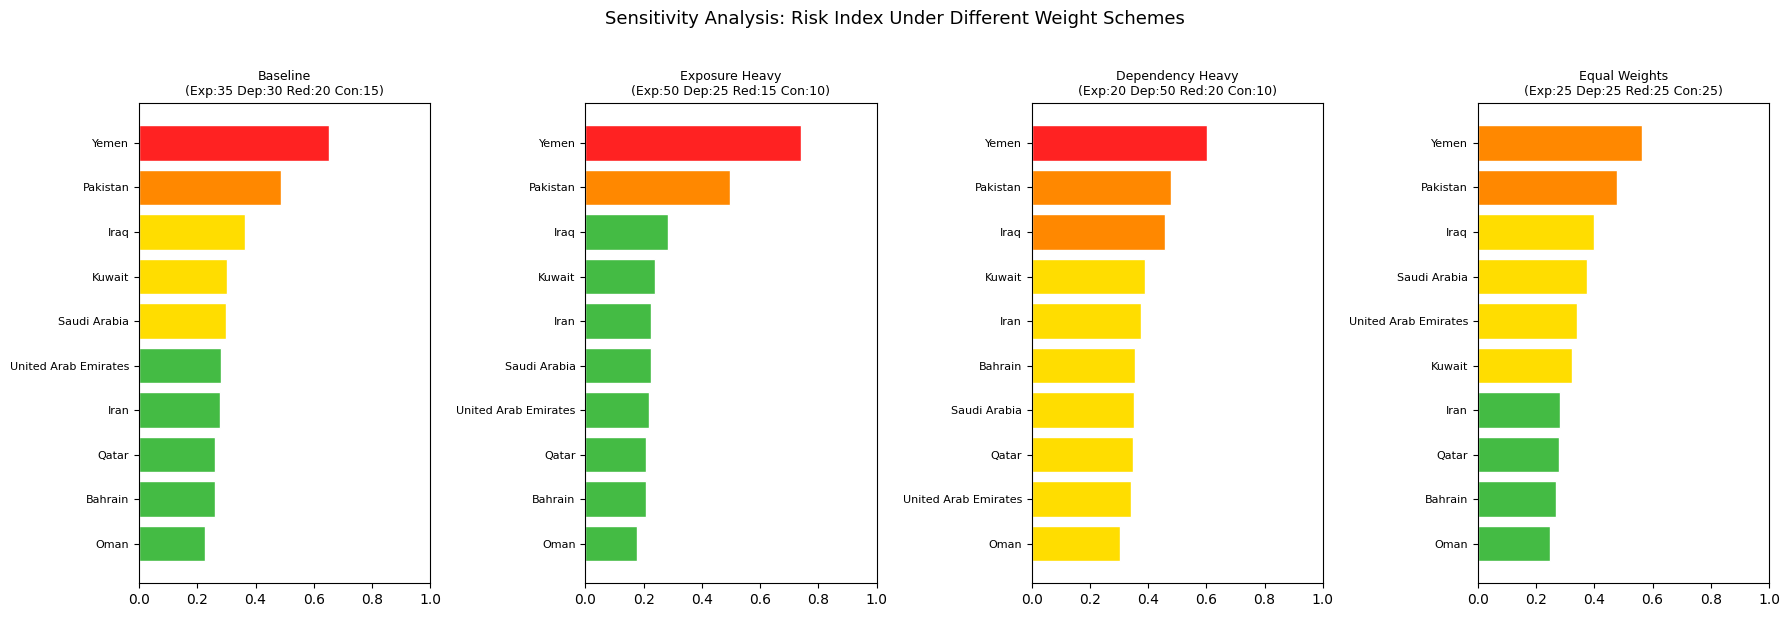

In [14]:
from itertools import product

# Baseline weights
baseline = {
    "n_exposicion":    0.35,
    "n_dependencia":   0.30,
    "n_redundancia":   0.20,
    "n_concentracion": 0.15,
}

# Alternative scenarios
escenarios = {
    "Baseline\n(Exp:35 Dep:30 Red:20 Con:15)": baseline,
    "Exposure Heavy\n(Exp:50 Dep:25 Red:15 Con:10)": {
        "n_exposicion": 0.50, "n_dependencia": 0.25,
        "n_redundancia": 0.15, "n_concentracion": 0.10,
    },
    "Dependency Heavy\n(Exp:20 Dep:50 Red:20 Con:10)": {
        "n_exposicion": 0.20, "n_dependencia": 0.50,
        "n_redundancia": 0.20, "n_concentracion": 0.10,
    },
    "Equal Weights\n(Exp:25 Dep:25 Red:25 Con:25)": {
        "n_exposicion": 0.25, "n_dependencia": 0.25,
        "n_redundancia": 0.25, "n_concentracion": 0.25,
    },
}

# Calcular índice para cada escenario
resultados = pd.DataFrame({"country": df_indice["country"]})

for nombre, pesos in escenarios.items():
    resultados[nombre] = sum(
        df_indice[col] * peso for col, peso in pesos.items()
    ).round(3)

# Ranking por escenario
print("RANKINGS BY SCENARIO:\n")
for col in resultados.columns[1:]:
    ranked = resultados.sort_values(col, ascending=False)["country"].tolist()
    print(f"{col.split(chr(10))[0]}:")
    for i, pais in enumerate(ranked, 1):
        print(f"  {i}. {pais}")
    print()

# Gráfico comparativo
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

for ax, col in zip(axes, resultados.columns[1:]):
    sorted_df = resultados.sort_values(col, ascending=True)
    colors = ["#ff2222" if v >= 0.6 else "#ff8800" if v >= 0.45
              else "#ffdd00" if v >= 0.30 else "#44bb44"
              for v in sorted_df[col]]
    ax.barh(sorted_df["country"], sorted_df[col], color=colors, edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlim(0, 1)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Sensitivity Analysis: Risk Index Under Different Weight Schemes",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 7.1 Sensitivity Findings

In [15]:
# Estabilidad del ranking
print("RANKING STABILITY ANALYSIS\n")
print("Countries that maintain their position across ALL scenarios:")

rankings = {}
for col in resultados.columns[1:]:
    rankings[col] = resultados.sort_values(col, ascending=False)["country"].tolist()

# Verificar posición de cada país en cada escenario
for pais in resultados["country"]:
    posiciones = [ranking.index(pais) + 1 for ranking in rankings.values()]
    min_pos = min(posiciones)
    max_pos = max(posiciones)
    variacion = max_pos - min_pos
    estabilidad = "STABLE" if variacion <= 1 else f"varies {min_pos}-{max_pos}"
    print(f"  {pais:<25} {estabilidad}")

print("\nKey insight:")
print("- Countries with HIGH stability: their vulnerability is robust regardless of methodology")
print("- Countries with LOW stability: their ranking depends heavily on how we weight the components")

RANKING STABILITY ANALYSIS

Countries that maintain their position across ALL scenarios:
  Yemen                     STABLE
  Pakistan                  STABLE
  Iraq                      STABLE
  Kuwait                    varies 4-6
  Saudi Arabia              varies 4-7
  United Arab Emirates      varies 5-9
  Iran                      varies 5-7
  Qatar                     STABLE
  Bahrain                   varies 6-9
  Oman                      STABLE

Key insight:
- Countries with HIGH stability: their vulnerability is robust regardless of methodology
- Countries with LOW stability: their ranking depends heavily on how we weight the components


### 7.2 Interpretation

**Robustly vulnerable (stable high ranking):** Yemen and Pakistan maintain top positions across all weighting schemes. Their vulnerability is structural, not a methodological artifact.

**Robustly resilient (stable low ranking):** Oman and Qatar remain consistently low-risk regardless of weights.

**Methodologically sensitive (unstable ranking):** Kuwait, Saudi Arabia, UAE, Iran, and Bahrain shift significantly depending on whether conflict exposure or cable dependency is prioritized. These countries have mixed risk profiles that require deeper case-by-case analysis.

This sensitivity analysis confirms that the index is robust for extreme cases but should be interpreted with caution for mid-range countries.

## 8. Temporal Analysis: How Has Risk Evolved?

How has conflict exposure near cable landing points changed over time?
We calculate the exposure component year by year for each country.

In [16]:
import geopandas as gpd
from shapely.geometry import Point

RADIO_M = 50 * 1000  # 50km en metros

# Preparar landing points con geometría
df_coords = pd.read_csv('../data/processed/landing_points_coords.csv')
lp = df_landing[df_landing["country"].isin(ZONA)].merge(df_coords, on="landing_id", how="left")
lp = lp.dropna(subset=["latitude", "longitude"])
lp["geometry"] = lp.apply(lambda r: Point(r["longitude"], r["latitude"]), axis=1)
gdf_lp = gpd.GeoDataFrame(lp, crs="EPSG:4326").to_crs("EPSG:3857")

# Preparar conflictos con geometría
df_conflicto["geometry"] = df_conflicto.apply(
    lambda r: Point(r["longitude"], r["latitude"]), axis=1
)
gdf_conf = gpd.GeoDataFrame(df_conflicto, crs="EPSG:4326").to_crs("EPSG:3857")
gdf_conf["year"] = gdf_conf["date_start"].dt.year

# Calcular eventos por país y año
print("Calculando exposición por año... (puede tardar 1-2 minutos)")

años = range(2015, 2027)
resultados_temporales = []

for año in años:
    conf_año = gdf_conf[gdf_conf["year"] == año]
    for pais in ZONA:
        lp_pais = gdf_lp[gdf_lp["country"] == pais]
        total_eventos = 0
        for _, lp_row in lp_pais.iterrows():
            buffer = lp_row["geometry"].buffer(RADIO_M)
            eventos = conf_año[conf_año["geometry"].within(buffer)]
            total_eventos += len(eventos)
        resultados_temporales.append({
            "year": año,
            "country": pais,
            "eventos": total_eventos
        })

df_temporal = pd.DataFrame(resultados_temporales)
print("Completado.")

Calculando exposición por año... (puede tardar 1-2 minutos)
Completado.


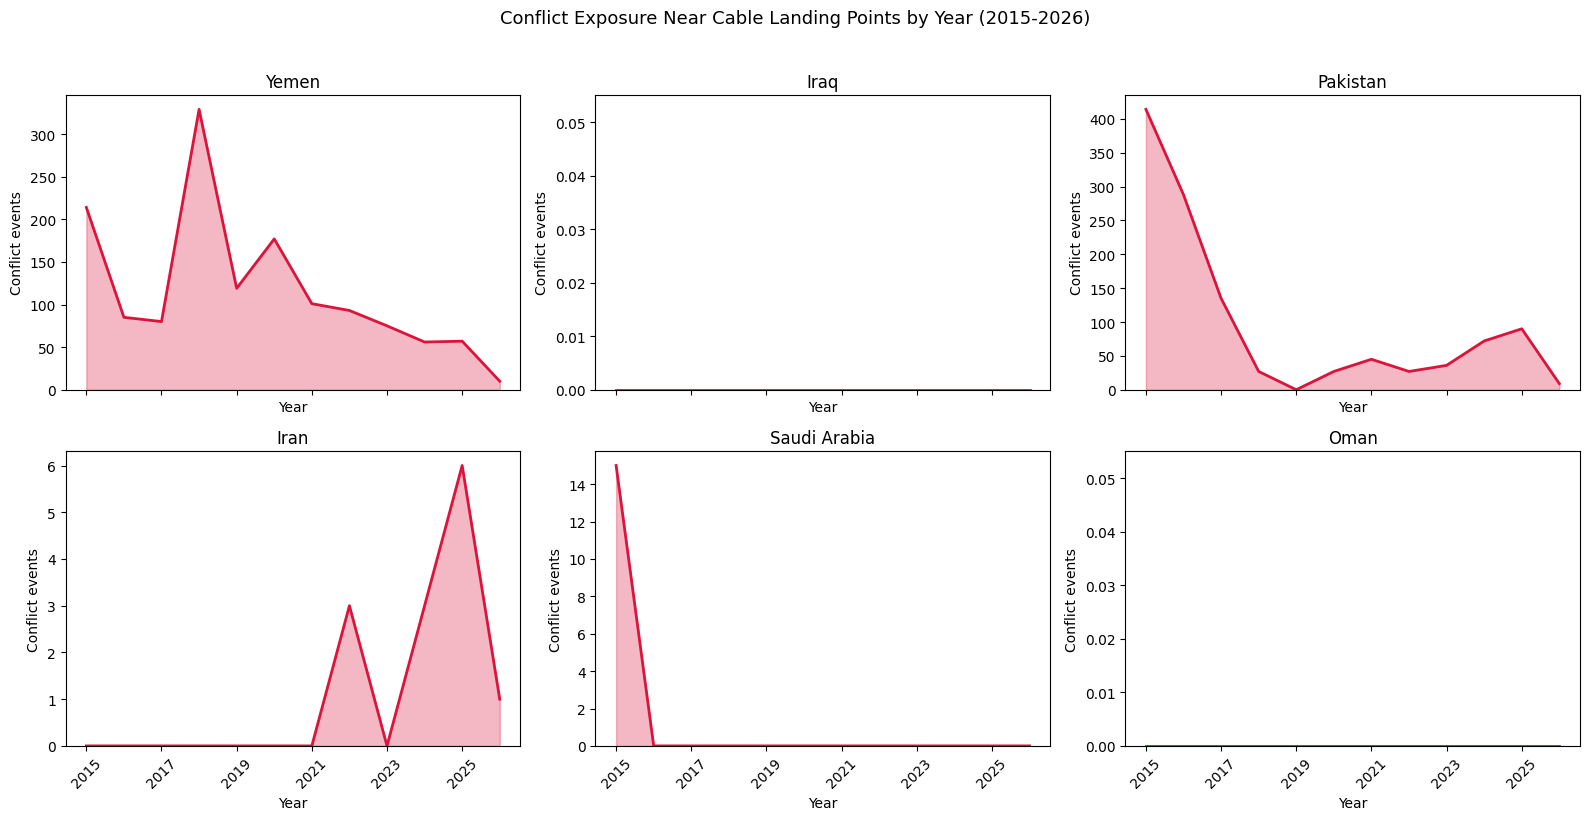


Conflict events near landing points by country and year:

year                  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
country                                                                                     
Bahrain                  0     0     0     0     0     0     0     0     0     0     0     0
Iran                     0     0     0     0     0     0     0     3     0     3     6     1
Iraq                     0     0     0     0     0     0     0     0     0     0     0     0
Kuwait                   6     0     0     0     0     0     0     0     0     0     0     6
Oman                     0     0     0     0     0     0     0     0     0     0     0     0
Pakistan               414   288   135    27     0    27    45    27    36    72    90     9
Qatar                    0     0     0     0     0     0     0     0     0     0     8     0
Saudi Arabia            15     0     0     0     0     0     0     0     0     0     0     0
United Arab

In [19]:
# Países más interesantes para comparar
paises_plot = ["Yemen", "Iraq", "Pakistan", "Iran", "Saudi Arabia", "Oman"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, pais in zip(axes, paises_plot):
    data = df_temporal[df_temporal["country"] == pais].sort_values("year")
    ax.fill_between(data["year"], data["eventos"], alpha=0.3, color="crimson")
    ax.plot(data["year"], data["eventos"], color="crimson", linewidth=2)
    ax.set_title(pais, fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Conflict events")
    ax.set_xticks(range(2015, 2027, 2))
    ax.set_ylim(bottom=0)  # <- agrega esta línea
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Conflict Exposure Near Cable Landing Points by Year (2015-2026)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nConflict events near landing points by country and year:\n")
pivot = df_temporal.pivot(index="country", columns="year", values="eventos")
print(pivot.to_string())


### 8.1 Temporal Findings

In [20]:
print("TEMPORAL ANALYSIS - KEY OBSERVATIONS\n")

for pais in paises_plot:
    data = df_temporal[df_temporal["country"] == pais].sort_values("year")
    max_año = data.loc[data["eventos"].idxmax(), "year"]
    max_val = data["eventos"].max()
    total = data["eventos"].sum()
    print(f"{pais:<25} Peak: {max_año} ({max_val} events)  Total: {total}")

TEMPORAL ANALYSIS - KEY OBSERVATIONS

Yemen                     Peak: 2018 (329 events)  Total: 1396
Iraq                      Peak: 2015 (0 events)  Total: 0
Pakistan                  Peak: 2015 (414 events)  Total: 1170
Iran                      Peak: 2025 (6 events)  Total: 13
Saudi Arabia              Peak: 2015 (15 events)  Total: 15
Oman                      Peak: 2015 (0 events)  Total: 0


### 8.2 Interpretation

- **Yemen:** Peak in 2018 (329 events), coinciding with the most intense phase of the civil war and Houthi operations near the Red Sea coast. Cable landing points in Al Hudaydah were directly in the conflict zone.
- **Pakistan:** Peak in 2015 (414 events), driven by military operations in Baluchistan near the Karachi coastal area where submarine cables land.
- **Iran:** Only 13 total events across the entire period. This reflects a critical limitation: the Iran-Israel-US conflict (2025) is primarily aerial and naval, not captured as terrestrial armed conflict in UCDP. Iran's actual risk is significantly underestimated by this dataset.
- **Iraq and Oman:** Zero events near landing points across all years. Iraq's conflict was inland; Oman has no significant armed conflict.

## 9. Conclusions

### What this analysis demonstrates

**1. Yemen and Pakistan are the most vulnerable countries in the Gulf zone** regardless of how the index components are weighted. This is a structural finding: both countries have few cables, all concentrated in the risk zone, with significant conflict activity near their coastal landing infrastructure.

**2. Oman is the most resilient country** despite being geographically closest to the Strait. High cable redundancy (20 cables) and absence of nearby conflict make it structurally resistant to digital isolation.

**3. The mid-range group (Kuwait, Saudi Arabia, UAE, Iran, Bahrain) shows methodological sensitivity.** Their rankings shift depending on whether conflict exposure or cable dependency is prioritized. These countries require case-by-case analysis rather than a single index score.

**4. Conflict exposure near cable landing points has been highest in Yemen (peak 2018) and Pakistan (peak 2015),** coinciding with documented armed conflict phases in those regions.

**5. Iran is likely underestimated by this index.** UCDP captures verified terrestrial armed conflict. Iran's actual risk profile includes naval operations, drone activity, proxy conflicts, and geopolitical pressure that are not reflected in the dataset. This is a data limitation, not a finding about Iran's risk level.

### What this analysis cannot demonstrate

- Risk along submarine cable routes on the seafloor (requires AIS vessel traffic data)
- Risk from naval operations, cyberattacks, or sanctions-related disruptions
- Political or strategic motivations of any state actor
- Causal relationships between conflict and cable damage

### Final note on methodology

This index is a proxy measure of coastal infrastructure vulnerability, not a comprehensive geopolitical risk assessment. It should be interpreted alongside qualitative analysis of the regional context, particularly for countries like Iran where quantitative conflict data systematically underrepresents actual risk.

## 10. References

### Data Sources
- TeleGeography Submarine Cable Map. (2026). *Submarine Cable Map API v3*. https://www.submarinecablemap.com
- Uppsala Conflict Data Program. (2025). *UCDP Georeferenced Event Dataset (GED) Global version 25.1*. Department of Peace and Conflict Research, Uppsala University. https://ucdp.uu.se/downloads
- Uppsala Conflict Data Program. (2026). *UCDP Candidate Events Dataset, version 26.0.2*. https://ucdp.uu.se/downloads
- AISstream. (2026). *Real-time AIS vessel tracking API*. https://aisstream.io

### Methodological References
- Raleigh, C., Linke, A., Hegre, H., & Karlsen, J. (2010). Introducing ACLED: Armed Conflict Location and Event Data. *Journal of Peace Research, 47*(5), 651-660.
- Sundaram, V., & Roeloffzen, M. (2010). *A history of submarine cables*. International Cable Protection Committee (ICPC).
- International Cable Protection Committee. (2023). *Submarine cable faults: Causes and prevention*. ICPC Publication No. 2. https://www.iscpc.org
- Mauldin, A. (2026, March). *Submarine cables and the Strait of Hormuz: Risk assessment*. TeleGeography Blog. https://blog.telegeography.com
- Crowley, J. (2026, March 19). Hormuz submarine cables face heightened risk from vessel build-up. *AGBI*. https://agbi.com

### Conflict Data Methodology
- Davies, S., Pettersson, T., & Öberg, M. (2023). Organized violence 1989-2022 and the return of conflicts between states. *Journal of Peace Research, 60*(4).